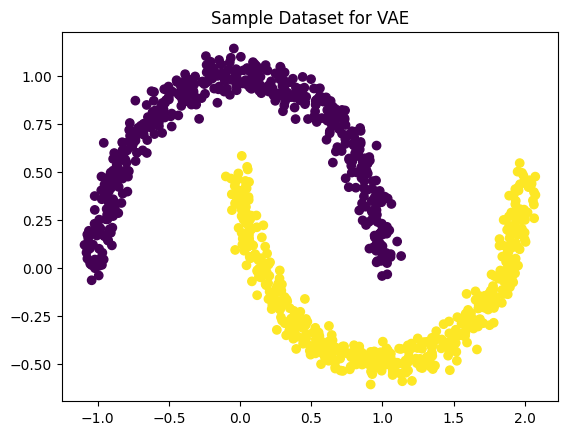

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.05)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Sample Dataset for VAE")
plt.show()


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

class VAE(nn.Module):
    def __init__(self, input_dim=2, latent_dim=2, hidden_dim=32):
        super(VAE, self).__init__()
        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        # Decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std  # Reparameterization trick

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return self.fc3(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


In [3]:
def loss_function(recon_x, x, mu, logvar):
    # Reconstruction loss
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    # KL divergence loss
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div


Epoch 0, Loss: 1734.943359375
Epoch 10, Loss: 1420.373046875
Epoch 20, Loss: 1281.9542236328125
Epoch 30, Loss: 1165.5125732421875
Epoch 40, Loss: 1067.82568359375
Epoch 50, Loss: 1053.3486328125
Epoch 60, Loss: 1025.779052734375
Epoch 70, Loss: 989.2266845703125
Epoch 80, Loss: 998.28369140625
Epoch 90, Loss: 987.160400390625


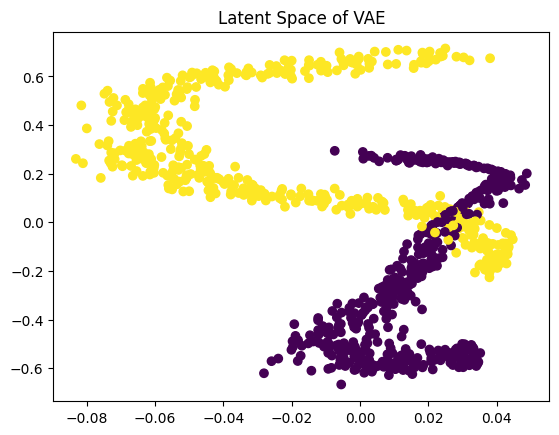

In [4]:
vae = VAE()
optimizer = optim.Adam(vae.parameters(), lr=1e-3)
X_tensor = torch.tensor(X, dtype=torch.float32)

for epoch in range(100):
    optimizer.zero_grad()
    recon, mu, logvar = vae(X_tensor)
    loss = loss_function(recon, X_tensor, mu, logvar)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

# Plot encoded latent space
with torch.no_grad():
    mu, _ = vae.encode(X_tensor)
    plt.scatter(mu[:, 0], mu[:, 1], c=y)
    plt.title("Latent Space of VAE")
    plt.show()


In [ ]:
“Imagine you are trying to understand someone's personality (z) just by watching their behavior (x).
The Bayesian approach tells you how to reverse-engineer that (via  p(z∣x)).
But if the math is too complex, VAE says: ‘Let me train a neural network to guess it well enough’ — that’s q(z∣x).”

In [ ]:
 If Bayesian networks already model  p(z∣x), why invent VAEs?

In [ ]:
Bayesian inference is often intractable for high-dimensional, real-world data like images, audio, or text.

In [ ]:
The Problem: Intractable (hard) Posterior

In a Bayesian model:

You want 
p(z∣x)= (p(x∣z)p(z))/ p(x)

But computing 

p(x)=∫p(x∣z)p(z)dz is very hard when:  z is high-dimensional

p(x∣z) is complex (e.g., a deep network)

So computing the exact posterior  p(z∣x) is intractable

In [ ]:
Why VAEs Came In

VAEs were introduced to: Approximate the intractable posterior 

p(z∣x) using a neural network q(z∣x)

They do this by:

Introducing an encoder 
qϕ(z∣x) — approximates p(z∣x)

Introducing a decoder 
pθ(x∣z) — reconstructs 𝑥

Using a clever optimization objective: ELBO (Evidence Lower Bound)

In [ ]:
What is ELBO? ELBO stands for Evidence Lower Bound.

In Variational Inference (like in VAE), you want to maximize the likelihood of the data:

logp(x)

But this is hard because:

logp(x)=log∫p(x,z)dz

That integral is intractable.


In [ ]:
So, what does VAE do?

VAE doesn’t optimize 

logp(x) directly.
Instead, it optimizes a lower bound to it — the ELBO:

logp(x) ≥E q(z∣x)​ [logp(x∣z)]−KL(q(z∣x)∥p(z))


In [ ]:
We maximize the ELBO, or equivalently, minimize this loss:

L(x)=−E q(z∣x)​ [logp(x∣z)]+KL(q(z∣x)∥p(z))

In [ ]:
so to understand this a bit better

Think of trying to reach the height of a mountain (logp(x)),
but the actual mountain is covered in fog — you can’t see or climb it directly.

Instead, you climb a visible hill (ELBO) that lies below the mountain.
As you climb the hill higher, you get closer to the mountain’s peak — even though you can't reach it exact

In [ ]:
Mathematically:
We define an approximate posterior 

q(z∣x) to replace the intractable real one p(z∣x), and derive:

logp(x)=ELBO+KL(q(z∣x)∥p(z∣x))
And since KL divergence is always ≥ 0, we get:

logp(x)≥ELBO
That’s why ELBO is called the lower bound — it’s always less than or equal to the true log-likelihood of the data.

In [ ]:
The ELBO is:


ELBO=E q(z∣x)​ [logp(x∣z)]−KL(q(z∣x)∥p(z))
We want to maximize this (make it as large as possible).

Now look at the loss function again:

L(x)=−(E q(z∣x)​ [logp(x∣z)]−KL(q(z∣x)∥p(z)))
Which is just:

L(x)=−ELBO
So you're minimizing the negative ELBO — which is mathematically equivalent to maximizing the ELBO.

In [ ]:
# Example


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import numpy as np


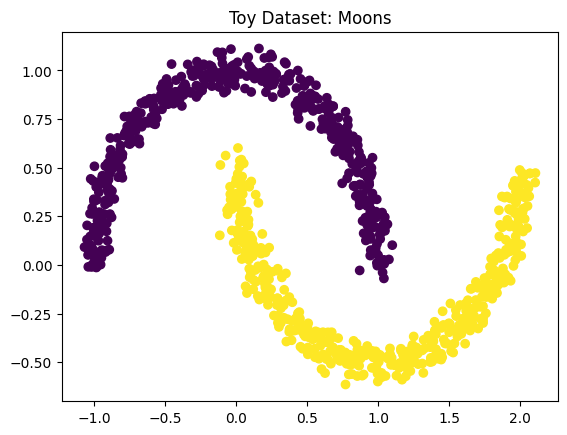

In [6]:
X, y = make_moons(n_samples=1000, noise=0.05)
X = torch.tensor(X, dtype=torch.float32)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Toy Dataset: Moons")
plt.show()


In [7]:
class VAE(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32, latent_dim=2):
        super(VAE, self).__init__()
        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return self.fc3(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


In [8]:
def vae_loss(x_recon, x, mu, logvar):
    # Reconstruction loss (MSE)
    recon_loss = F.mse_loss(x_recon, x, reduction='sum')
    # KL divergence loss
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss, recon_loss, kl_loss


In [9]:
vae = VAE()
optimizer = optim.Adam(vae.parameters(), lr=1e-3)
num_epochs = 100

for epoch in range(num_epochs):
    optimizer.zero_grad()
    x_recon, mu, logvar = vae(X)
    loss, recon, kl = vae_loss(x_recon, X, mu, logvar)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Total Loss = {loss.item():.2f}, Recon = {recon.item():.2f}, KL = {kl.item():.2f}")


Epoch 0: Total Loss = 1549.13, Recon = 1483.25, KL = 65.88
Epoch 10: Total Loss = 1325.16, Recon = 1287.35, KL = 37.81
Epoch 20: Total Loss = 1168.95, Recon = 1137.86, KL = 31.09
Epoch 30: Total Loss = 1079.50, Recon = 1047.32, KL = 32.18
Epoch 40: Total Loss = 1024.23, Recon = 992.80, KL = 31.43
Epoch 50: Total Loss = 1011.12, Recon = 973.62, KL = 37.51
Epoch 60: Total Loss = 1006.49, Recon = 956.59, KL = 49.91
Epoch 70: Total Loss = 974.24, Recon = 912.13, KL = 62.12
Epoch 80: Total Loss = 973.08, Recon = 898.59, KL = 74.49
Epoch 90: Total Loss = 991.40, Recon = 911.48, KL = 79.91


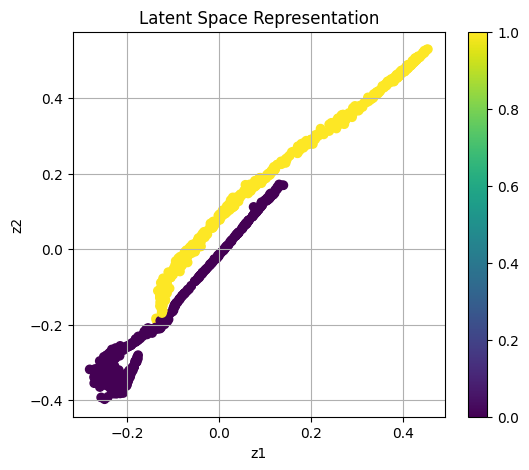

In [10]:
with torch.no_grad():
    mu, _ = vae.encode(X)
    mu = mu.numpy()

plt.figure(figsize=(6, 5))
plt.scatter(mu[:, 0], mu[:, 1], c=y, cmap='viridis')
plt.colorbar()
plt.title("Latent Space Representation")
plt.xlabel("z1")
plt.ylabel("z2")
plt.grid(True)
plt.show()


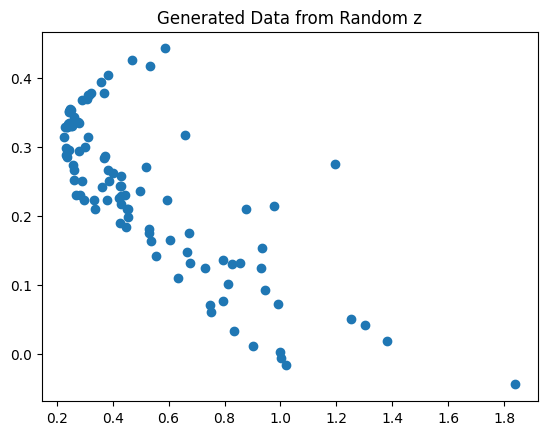

In [11]:
z_samples = torch.randn(100, 2)
with torch.no_grad():
    generated = vae.decode(z_samples)

generated = generated.numpy()
plt.scatter(generated[:, 0], generated[:, 1])
plt.title("Generated Data from Random z")
plt.show()


In [14]:
# Speech
!pip install torchaudio librosa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 17.2 MB/s eta 0:00:0031m20.3 MB/s eta 0:00:01


In [27]:
# need to do this.
!pip uninstall deeplake -y

Found existing installation: deeplake 4.2.14
Uninstalling deeplake-4.2.14:
  Successfully uninstalled deeplake-4.2.14


In [28]:
!pip install "deeplake<4"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 643.4/643.4 kB 14.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 33.7 MB/s eta 0:00:001m39.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 35.1 MB/s eta 0:00:00
  Created wheel for deeplake: filename=deeplake-3.9.50-py3-none-any.whl size=772866 sha256=b20aa63da5acd73341036c257aa011e931a0e367f51df4ac6ee4a6dfed72bbae
  Stored in directory: /home/monsley/.cache/pip/wheels/c9/2b/02/f4d5cbf2c697565a0ce89d44b7b269e82d2844ef441316fbdb
Successfully built deeplake
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.11.0
    Uninstalling typing_extensions-4.11.0:
      Suc

In [1]:
import hub
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

ds = hub.load("hub://activeloop/spoken_mnist")


/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/deeplake/util/check_latest_version.py:32: UserWarning: A newer version of deeplake (4.2.14) is available. It's recommended that you update to the latest version using `pip install -U deeplake`.
  warnings.warn(
|

Opening dataset in read-only mode as you don't have write permissions.


-

This dataset can be visualized in Jupyter Notebook by ds.visualize() or at https://app.activeloop.ai/activeloop/spoken_mnist



-

hub://activeloop/spoken_mnist loaded successfully.



In [5]:
class HubSpeechDataset(Dataset):
    def __init__(self, hub_ds):
        self.ds = hub_ds

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        spectrogram = self.ds['spectrograms'][idx].numpy()

        # FIX: Remove extra dimensions (assume it’s in shape [64, 64, 4])
        if spectrogram.ndim == 3 and spectrogram.shape[-1] == 4:
            spectrogram = spectrogram[..., 0]  # Take just the first "channel"

        spectrogram = torch.tensor(spectrogram).unsqueeze(0).float()  # [1, H, W]
        spectrogram = (spectrogram - spectrogram.mean()) / (spectrogram.std() + 1e-6)
        label = self.ds['labels'][idx].numpy()
        return spectrogram, label


In [6]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleVAE(nn.Module):
    def __init__(self, latent_dim=16):
        super(SimpleVAE, self).__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # [B,16,H/2,W/2]
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # [B,32,H/4,W/4]
            nn.ReLU()
        )
        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(32 * 16 * 16, latent_dim)
        self.fc_logvar = nn.Linear(32 * 16 * 16, latent_dim)

        self.decoder_input = nn.Linear(latent_dim, 32 * 16 * 16)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        x = self.flatten(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = self.decoder_input(z)
        x = x.view(-1, 32, 16, 16)
        x = self.decoder(x)
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


In [7]:
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss

def train_vae(model, dataloader, epochs=10, lr=1e-3):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        total_loss = 0
        for x, _ in dataloader:
            x = x.to(device)
            recon, mu, logvar = model(x)
            loss = vae_loss(recon, x, mu, logvar)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss / len(dataloader.dataset):.2f}")


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = HubSpeechDataset(ds)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

vae = SimpleVAE(latent_dim=16).to(device)
train_vae(vae, loader, epochs=10)


Epoch 1, Loss: 3613.11
Epoch 2, Loss: 2921.35
Epoch 3, Loss: 2825.25
Epoch 4, Loss: 2789.86
Epoch 5, Loss: 2773.05
Epoch 6, Loss: 2763.63
Epoch 7, Loss: 2757.17
Epoch 8, Loss: 2752.39
Epoch 9, Loss: 2749.52
Epoch 10, Loss: 2746.64


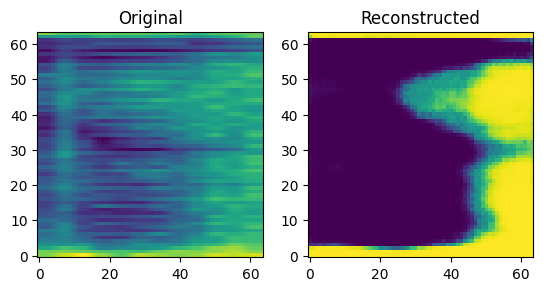

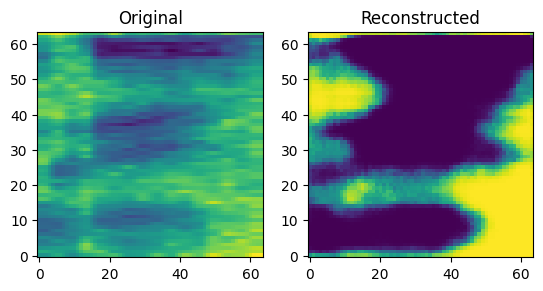

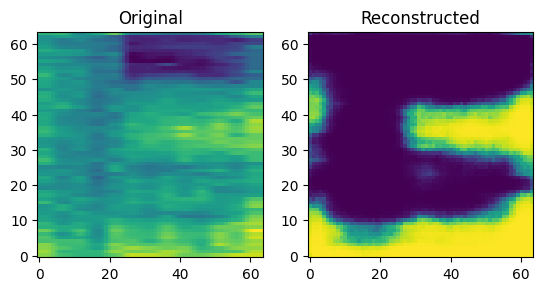

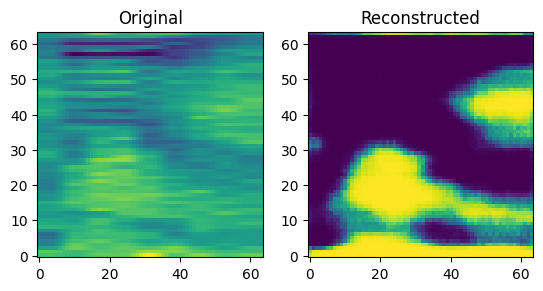

In [9]:
import matplotlib.pyplot as plt

vae.eval()
x, _ = next(iter(loader))
x = x.to(device)
with torch.no_grad():
    recon, _, _ = vae(x)

for i in range(4):
    fig, axs = plt.subplots(1, 2)
    axs[0].imshow(x[i,0].cpu(), origin='lower')
    axs[0].set_title("Original")
    axs[1].imshow(recon[i,0].cpu(), origin='lower')
    axs[1].set_title("Reconstructed")
    plt.show()


In [11]:
!pip install torchaudio

In [16]:
import torchaudio
import torchaudio.transforms as T

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

path = './pink_noise.wav'
waveform, sample_rate = torchaudio.load(path)
waveform = waveform.to(device)
print(waveform.shape, sample_rate)


torch.Size([1, 160000]) 16000


In [18]:

mel_transform = T.MelSpectrogram(
    sample_rate=16000,
    n_fft=1024,
    hop_length=512,
    n_mels=64
).to(device)  # move the transform to GPU

waveform = waveform.to(device)
mel_spec = mel_transform(waveform)       # [1, 64, T]
mel_spec = torch.log1p(mel_spec)         # Log compression
mel_spec = mel_spec[:, :, :32]   



In [19]:
class VAE(nn.Module):
    def __init__(self, input_channels=64, time_dim=32, latent_dim=16):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(input_channels, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv1d(128, 64, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)
        self.decoder_input = nn.Linear(latent_dim, 64)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(128, input_channels, 3, padding=1),
            nn.Upsample(size=32, mode='nearest'),
            nn.Tanh()
        )

    def encode(self, x):
        h = self.encoder(x).squeeze(-1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z).unsqueeze(-1)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


In [20]:
def vae_loss(x_recon, x, mu, logvar):
    recon = nn.functional.mse_loss(x_recon, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl


In [26]:
import torch.optim as optim
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

vae.train()
for epoch in range(1000):
    optimizer.zero_grad()
    x_recon, mu, logvar = vae(mel_spec)
    loss = vae_loss(x_recon, mel_spec, mu, logvar)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.2f}")


Epoch 0: Loss = 7.19
Epoch 10: Loss = 3.88
Epoch 20: Loss = 2.37
Epoch 30: Loss = 0.91
Epoch 40: Loss = 1.59
Epoch 50: Loss = 1.10
Epoch 60: Loss = 0.73
Epoch 70: Loss = 0.86
Epoch 80: Loss = 0.84
Epoch 90: Loss = 1.78
Epoch 100: Loss = 1.67
Epoch 110: Loss = 0.33
Epoch 120: Loss = 0.39
Epoch 130: Loss = 1.35
Epoch 140: Loss = 0.39
Epoch 150: Loss = 0.46
Epoch 160: Loss = 0.42
Epoch 170: Loss = 0.27
Epoch 180: Loss = 0.25
Epoch 190: Loss = 0.14
Epoch 200: Loss = 0.31
Epoch 210: Loss = 0.13
Epoch 220: Loss = 0.23
Epoch 230: Loss = 0.21
Epoch 240: Loss = 0.33
Epoch 250: Loss = 0.09
Epoch 260: Loss = 0.09
Epoch 270: Loss = 0.07
Epoch 280: Loss = 0.27
Epoch 290: Loss = 0.14
Epoch 300: Loss = 0.11
Epoch 310: Loss = 0.46
Epoch 320: Loss = 0.09
Epoch 330: Loss = 0.07
Epoch 340: Loss = 0.06
Epoch 350: Loss = 0.05
Epoch 360: Loss = 0.06
Epoch 370: Loss = 0.03
Epoch 380: Loss = 0.03
Epoch 390: Loss = 0.04
Epoch 400: Loss = 0.03
Epoch 410: Loss = 0.03
Epoch 420: Loss = 0.02
Epoch 430: Loss = 0.02

In [ ]:
'''vae.eval()
with torch.no_grad():
    decoded_mel = vae(mel_spec)[0].squeeze(0).cpu().numpy()

# Convert mel → STFT → waveform
S = librosa.feature.inverse.mel_to_stft(decoded_mel, sr=16000, n_fft=1024)
audio = librosa.griffinlim(S, n_iter=32, hop_length=512, win_length=1024)

# Save reconstructed audio
sf.write("reconstructed_audio.wav", audio, 16000)
print("Saved reconstructed_audio.wav")
'''

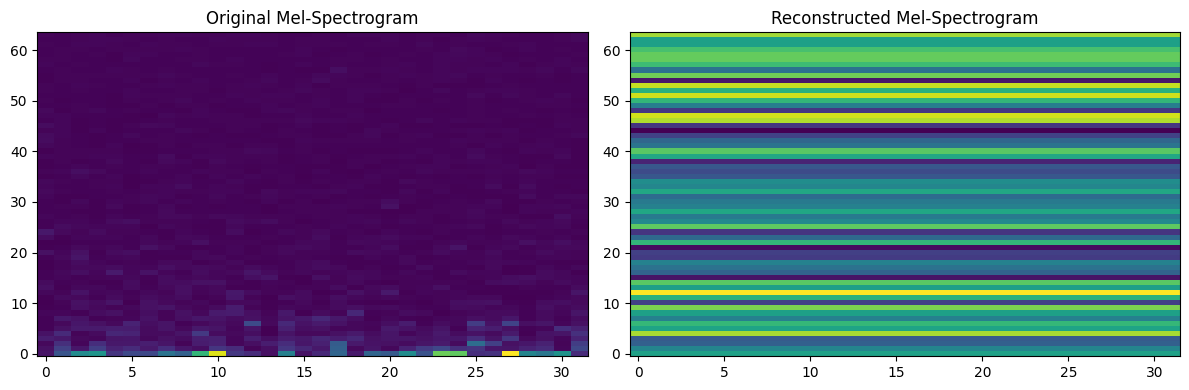

In [27]:
import matplotlib.pyplot as plt

# Get the decoded mel from VAE
vae.eval()
with torch.no_grad():
    x_recon, _, _ = vae(mel_spec)

original_mel = mel_spec.squeeze().cpu().numpy()
recon_mel = x_recon.squeeze().cpu().numpy()

# Plot both
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].imshow(original_mel, aspect='auto', origin='lower')
axs[0].set_title("Original Mel-Spectrogram")

axs[1].imshow(recon_mel, aspect='auto', origin='lower')
axs[1].set_title("Reconstructed Mel-Spectrogram")

plt.tight_layout()
plt.show()


In [28]:
# metrics
!pip install scikit-image
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import numpy as np

original_mel = mel_spec.squeeze().cpu().numpy()
recon_mel = x_recon.squeeze().cpu().numpy()

psnr_score = psnr(original_mel, recon_mel, data_range=original_mel.max() - original_mel.min())
print(f"PSNR: {psnr_score:.2f} dB")

# Normalize to [0, 1] for SSIM
orig_norm = (original_mel - original_mel.min()) / (original_mel.max() - original_mel.min() + 1e-8)
recon_norm = (recon_mel - recon_mel.min()) / (recon_mel.max() - recon_mel.min() + 1e-8)

ssim_score = ssim(orig_norm, recon_norm, data_range=1.0)
print(f"SSIM: {ssim_score:.4f}")


PSNR: -18.46 dB
SSIM: 0.0013


In [ ]:
| Metric | Range     | Interpretation                         |
| ------ | --------- | -------------------------------------- |
| PSNR   | 10–40+ dB | Higher is better (above 20–30 is good) |
| SSIM   | 0–1       | 1 = perfect similarity                 |


In [ ]:
# In image processing

In [ ]:
pip install torch torchvision matplotlib scikit-image pillow


In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import numpy as np

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [31]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),  # Converts to [C, H, W], values ∈ [0, 1]
])

# Load your image
img = Image.open(r"eigen.jpeg").convert("RGB")
x = transform(img).unsqueeze(0).to(device)  # [1, 3, 64, 64]


In [32]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),  # 32×32
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 16×16
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),  # 8×8
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(128 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(128 * 8 * 8, latent_dim)

        # Decoder
        self.fc_dec = nn.Linear(latent_dim, 128 * 8 * 8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  # 16×16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),  # 32×32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),  # 64×64
            nn.Sigmoid()  # Output in [0, 1]
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_dec(z).view(-1, 128, 8, 8)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


In [33]:
vae = ConvVAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

def vae_loss(x_recon, x, mu, logvar):
    recon = nn.functional.mse_loss(x_recon, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl

vae.train()
for epoch in range(100):
    optimizer.zero_grad()
    x_recon, mu, logvar = vae(x)
    loss = vae_loss(x_recon, x, mu, logvar)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.2f}")


Epoch 0, Loss: 641.97
Epoch 10, Loss: 507.51
Epoch 20, Loss: 426.19
Epoch 30, Loss: 298.06
Epoch 40, Loss: 200.59
Epoch 50, Loss: 126.32
Epoch 60, Loss: 111.72
Epoch 70, Loss: 79.87
Epoch 80, Loss: 81.70
Epoch 90, Loss: 55.07


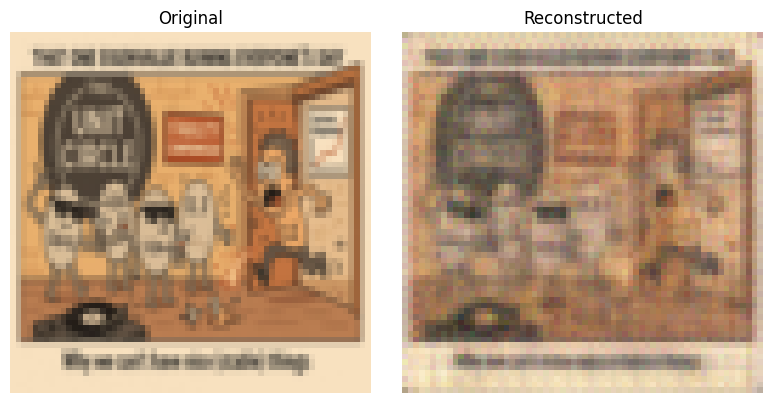

In [34]:
vae.eval()
with torch.no_grad():
    x_recon, _, _ = vae(x)

x_np = x.squeeze().permute(1, 2, 0).cpu().numpy()
x_recon_np = x_recon.squeeze().permute(1, 2, 0).cpu().numpy()

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(x_np)
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(x_recon_np)
axs[1].set_title("Reconstructed")
axs[1].axis("off")
plt.tight_layout()
plt.show()


In [35]:
p = psnr(x_np, x_recon_np, data_range=1.0)
s = ssim(x_np, x_recon_np, channel_axis=2, data_range=1.0)
print(f"PSNR = {p:.2f} dB | SSIM = {s:.4f}")


PSNR = 22.95 dB | SSIM = 0.8163


In [ ]:
# Another example

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load MNIST
transform = transforms.ToTensor()
mnist = datasets.MNIST(root='/home/monsley/Downloads/online/GenAI/26072025/SOM/data', train=True, download=True, transform=transform)
loader = DataLoader(mnist, batch_size=128, shuffle=True)

# Define VAE
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)
        self.fc2 = nn.Linear(latent_dim, 256)
        self.fc3 = nn.Linear(256, 28*28)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# Instantiate and optimizer
latent_dim = 2  # for easy visualization
vae = VAE(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

# VAE loss
def loss_fn(recon_x, x, mu, logvar):
    recon = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl

# Train for a few epochs
vae.train()
for epoch in range(5):
    for x, _ in loader:
        x = x.view(-1, 28*28).to(device)
        optimizer.zero_grad()
        x_recon, mu, logvar = vae(x)
        loss = loss_fn(x_recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch}: Loss = {loss.item():.2f}")


Epoch 0: Loss = 16112.47
Epoch 1: Loss = 15689.33
Epoch 2: Loss = 15909.39
Epoch 3: Loss = 15098.00
Epoch 4: Loss = 15602.97


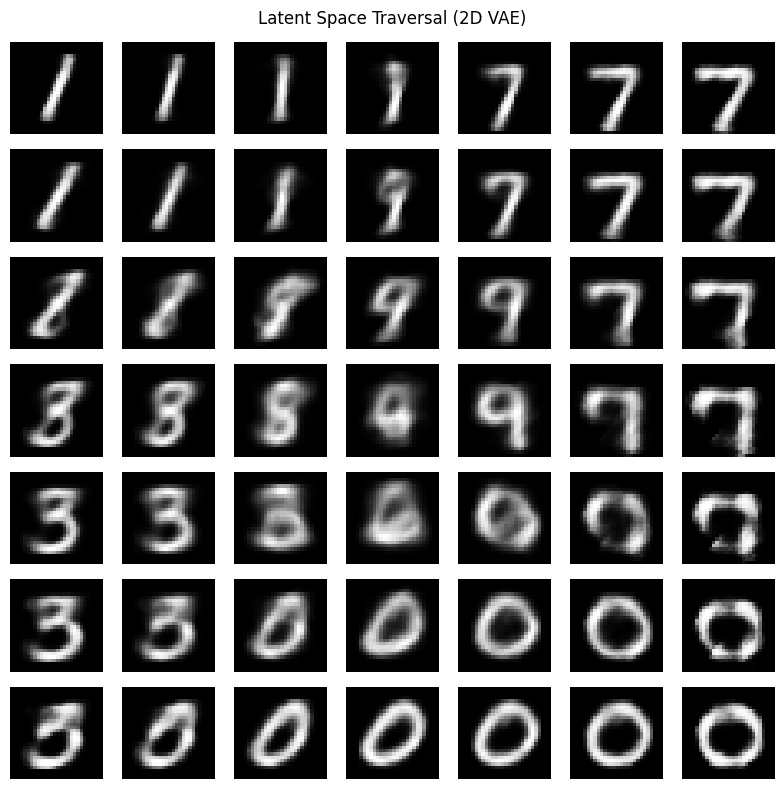

In [37]:
# latent space traversal

# Traverse each latent dimension (z ∈ ℝ^2)
vae.eval()
grid_size = 7
range_vals = torch.linspace(-3, 3, grid_size)

fig, axs = plt.subplots(grid_size, grid_size, figsize=(8, 8))

for i, z1 in enumerate(range_vals):
    for j, z2 in enumerate(range_vals):
        z = torch.tensor([[z1, z2]], dtype=torch.float32).to(device)
        with torch.no_grad():
            recon = vae.decode(z).view(28, 28).cpu().numpy()
        axs[i, j].imshow(recon, cmap='gray')
        axs[i, j].axis('off')

plt.suptitle("Latent Space Traversal (2D VAE)")
plt.tight_layout()
plt.show()


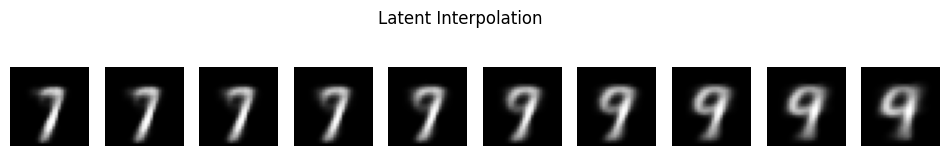

In [38]:
# Interpolation between digits

x, _ = next(iter(loader))
img1 = x[0].view(1, -1).to(device)
img2 = x[1].view(1, -1).to(device)

mu1, _ = vae.encode(img1)
mu2, _ = vae.encode(img2)

alphas = torch.linspace(0, 1, 10)
fig, axs = plt.subplots(1, 10, figsize=(12, 2))
for i, alpha in enumerate(alphas):
    z = mu1 * (1 - alpha) + mu2 * alpha
    img = vae.decode(z).view(28, 28).detach().cpu().numpy()
    axs[i].imshow(img, cmap='gray')
    axs[i].axis('off')
plt.suptitle("Latent Interpolation")
plt.show()


In [ ]:
# Just a overview of other techniques

In [ ]:
#   Conditional VAE (CVAE)
p(x|z, y)  ← condition on label y


In [ ]:
#  VQ-VAE (Vector Quantized Variational Autoencoder) 

Unlike VAEs that use continuous latent vectors, VQ-VAEs use a discrete latent space (like words in a dictionary or tokens).

This makes them ideal for sequence modeling, text-to-image models, and speech synthesis (e.g., DALL·E, Jukebox, SoundStream).

In [ ]:
Encoder outputs a latent vector

Instead of using it directly, it's quantized to the nearest vector in a codebook

Decoder reconstructs from the discrete code

This allows modeling using autoregressive models or transformers

# just like a regular VAE, but the bottleneck is a discrete lookup instead of a Gaussian sampling.

In [ ]:
pip install torch torchvision matplotlib


In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VectorQuantizer(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings
        self.commitment_cost = commitment_cost

        self.embeddings = nn.Embedding(num_embeddings, embedding_dim)
        self.embeddings.weight.data.uniform_(-1 / num_embeddings, 1 / num_embeddings)

    def forward(self, z):
        # Flatten input
        flat_z = z.view(-1, self.embedding_dim)

        # Compute distances to embedding vectors
        dist = (flat_z.unsqueeze(1) - self.embeddings.weight).pow(2).sum(2)

        # Get closest embedding
        indices = torch.argmin(dist, dim=1)
        quantized = self.embeddings(indices).view(z.shape)

        # Compute loss
        commitment_loss = self.commitment_cost * F.mse_loss(quantized.detach(), z)
        codebook_loss = F.mse_loss(quantized, z.detach())

        quantized = z + (quantized - z).detach()  # straight-through estimator
        return quantized, codebook_loss + commitment_loss


In [40]:
class VQVAE(nn.Module):
    def __init__(self, embedding_dim=64, num_embeddings=128, commitment_cost=0.25):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1),  # 14x14
            nn.ReLU(),
            nn.Conv2d(32, embedding_dim, 3, stride=1, padding=1),  # 14x14
        )
        self.vq = VectorQuantizer(num_embeddings, embedding_dim, commitment_cost)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(embedding_dim, 32, 4, stride=2, padding=1),  # 28x28
            nn.ReLU(),
            nn.Conv2d(32, 1, 3, stride=1, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        z_perm = z.permute(0, 2, 3, 1).contiguous()  # BCHW → BHWC for VQ
        quantized, loss = self.vq(z_perm)
        quantized = quantized.permute(0, 3, 1, 2).contiguous()  # BHWC → BCHW
        x_recon = self.decoder(quantized)
        return x_recon, loss


In [43]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

transform = transforms.Compose([transforms.ToTensor()])
mnist = datasets.MNIST('/home/monsley/Downloads/online/GenAI/26072025/SOM/data', train=True, download=False, transform=transform)
loader = DataLoader(mnist, batch_size=16, shuffle=True)

model = VQVAE().cuda()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    model.train()
    for x, _ in loader:
        x = x.cuda()
        opt.zero_grad()
        x_recon, vq_loss = model(x)
        recon_loss = F.mse_loss(x_recon, x)
        loss = recon_loss + vq_loss
        loss.backward()
        opt.step()
    print(f"Epoch {epoch} - Recon Loss: {recon_loss.item():.4f} | VQ Loss: {vq_loss.item():.4f}")


Epoch 0 - Recon Loss: 0.0009 | VQ Loss: 0.0019
Epoch 1 - Recon Loss: 0.0006 | VQ Loss: 0.0020
Epoch 2 - Recon Loss: 0.0005 | VQ Loss: 0.0018
Epoch 3 - Recon Loss: 0.0004 | VQ Loss: 0.0018
Epoch 4 - Recon Loss: 0.0005 | VQ Loss: 0.0020


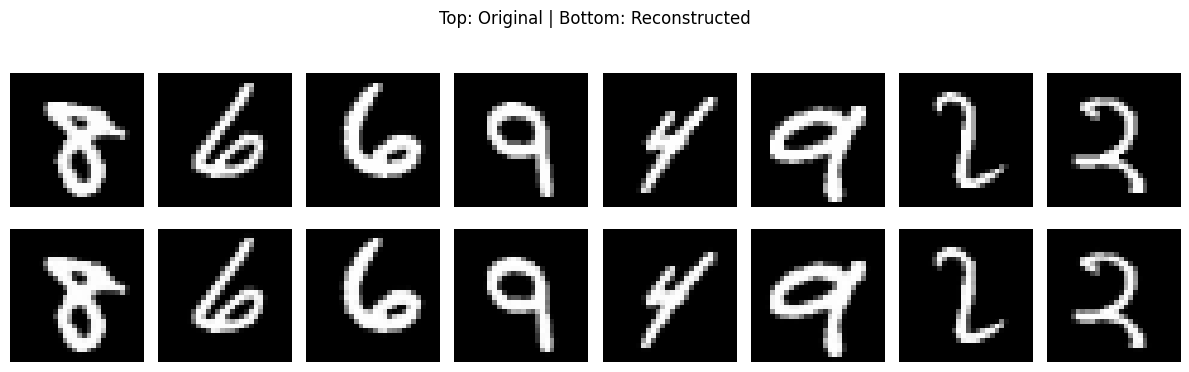

In [44]:
model.eval()
x, _ = next(iter(loader))
x = x[:8].cuda()
with torch.no_grad():
    x_recon, _ = model(x)

fig, axs = plt.subplots(2, 8, figsize=(12, 4))
for i in range(8):
    axs[0, i].imshow(x[i, 0].cpu(), cmap='gray')
    axs[1, i].imshow(x_recon[i, 0].cpu(), cmap='gray')
    axs[0, i].axis('off')
    axs[1, i].axis('off')

plt.suptitle("Top: Original | Bottom: Reconstructed")
plt.tight_layout()
plt.show()


In [ ]:
| Feature              | VAE             | VQ-VAE                      |
| -------------------- | --------------- | --------------------------- |
| Latent space         | Continuous      | Discrete (tokenized)        |
| Output blur          | Often blurry    | Sharper (via token control) |
| Modeling flexibility | Simple          | Complex, but powerful       |
| Interpolations       | Smooth          | Less smooth                 |
| Generation use case  | Latent sampling | Token-based transformers    |


In [ ]:
| Model                                                     | What It Does                                    | Relevance                                    |
| --------------------------------------------------------- | ----------------------------------------------- | -------------------------------------------- |
| **NADE** (Neural Autoregressive Density Estimator)        | Autoregressive model over input dimensions      | Good for tabular & image pixel modeling      |
| **MADE** (Masked Autoencoder for Distribution Estimation) | Fast version of NADE                            | Leads to PixelCNN                            |
| **PixelCNN/PixelRNN**                                     | Generates images pixel by pixel                 | Direct successor of NADE in vision           |
| **Normalizing Flows**                                     | Learn exact invertible mappings                 | Great theoretical contrast with VAE          |
| **Diffusion Models**                                      | Learn to reverse noise (SOTA for image gen)     | Modern standard (DALL·E 2, Stable Diffusion) |
| **Score-based Models**                                    | Continuous-time version of diffusion            | More math-heavy, very advanced               |
| **Energy-Based Models (EBM)**                             | Learn energy functions instead of probabilities | Flexible but hard to train                   |


# NADE — Neural Autoregressive Density Estimator

In [ ]:
Autoregressive factorization:

𝑝(𝑥)=∏
    =𝑝(𝑥𝑖∣𝑥<𝑖)

Each 𝑥𝑖 is modeled by an MLP taking  𝑥1,…,𝑥𝑖−1
Suitable for binary vectors (e.g., MNIST pixels binarized)



In [ ]:
For a binary input vector (e.g. 28×28 image flattened to 784), we model:

𝑝(𝑥)=∏𝑖=𝑝(𝑥𝑖∣𝑥1,𝑥2...,𝑥𝑖−1)

Each conditional probability  𝑝(𝑥𝑖∣𝑥<𝑖) is learned using an MLP.

In [ ]:
For an image (like MNIST), NADE treats each pixel as a Bernoulli random variable, and models:

"What is the probability of pixel  𝑥𝑖  being ON, given all previous pixels?"

This is like saying:

“If the first few pixels are black, how likely is this next one also black?”
“Is there a pattern forming that I should follow?”

In [ ]:
How it Works in Practice
You flatten the image (say, top-left to bottom-right)

For each position 𝑖, you:

Take pixels 
𝑥1,...,𝑥𝑖−1  as input

Use an MLP to predict 
𝑝(𝑥𝑖=1∣𝑥1,...,𝑥𝑖−1)


In [ ]:
# Autoregressive models don’t see the full input — they predict one pixel at a time based only on previous pixels.

In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === 1. Load and Binarize MNIST ===
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float()),  # Binarize
    transforms.Lambda(lambda x: x.view(-1))          # Flatten
])

train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)


100%|███████████████████████████████████████| 9.91M/9.91M [00:10<00:00, 949kB/s]
100%|██████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 94.4kB/s]
100%|███████████████████████████████████████| 1.65M/1.65M [00:04<00:00, 383kB/s]
100%|██████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 7.02MB/s]


In [47]:
# === Define NADE ===
class NADE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=500):
        super().__init__()
        self.input_dim = input_dim

        self.V = nn.Parameter(torch.randn(input_dim, hidden_dim) * 0.01)
        self.W = nn.Parameter(torch.randn(hidden_dim, input_dim) * 0.01)
        self.b = nn.Parameter(torch.zeros(hidden_dim))
        self.c = nn.Parameter(torch.zeros(input_dim))

    def forward(self, x):
        batch_size = x.size(0)
        a = torch.zeros(batch_size, self.W.size(0), device=x.device)
        h = torch.zeros_like(x)

        for i in range(self.input_dim):
            a = a + x[:, i-1:i] @ self.V[i-1:i] if i > 0 else a
            h_i = torch.sigmoid(a + self.b)
            logits = h_i @ self.W[:, i].unsqueeze(1) + self.c[i]
            prob = torch.sigmoid(logits.squeeze())
            h[:, i] = prob
        return h


In [48]:
# === Training Loop ===
nade = NADE().to(device)
optimizer = torch.optim.Adam(nade.parameters(), lr=1e-3)

for epoch in range(5):
    total_loss = 0
    nade.train()
    for x, _ in train_loader:
        x = x.to(device)
        x_hat = nade(x)
        loss = F.binary_cross_entropy(x_hat, x, reduction='sum')
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}: Loss = {total_loss / len(train_loader.dataset):.4f}")


Epoch 0: Loss = 163.2367
Epoch 1: Loss = 109.4959
Epoch 2: Loss = 93.8841
Epoch 3: Loss = 86.0842
Epoch 4: Loss = 81.3232


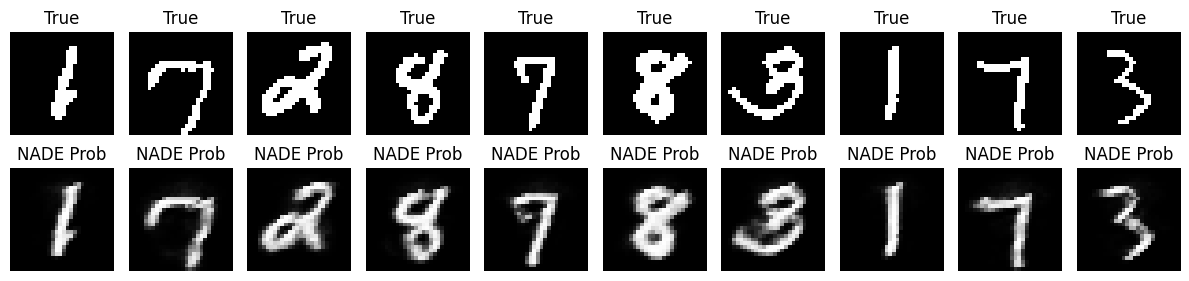

In [49]:
# Take a batch of data
nade.eval()
x, _ = next(iter(train_loader))
x = x[:10].to(device)
x_hat = nade(x).detach().cpu()

# Visualize predicted probabilities
fig, axs = plt.subplots(2, 10, figsize=(12, 3))
for i in range(10):
    axs[0, i].imshow(x[i].view(28, 28).cpu(), cmap='gray')
    axs[0, i].set_title("True")
    axs[0, i].axis('off')

    axs[1, i].imshow(x_hat[i].view(28, 28), cmap='gray')
    axs[1, i].set_title("NADE Prob")
    axs[1, i].axis('off')

plt.tight_layout()
plt.show()


In [50]:
# Compute average negative log likelihood
def estimate_nll(model, data_loader):
    model.eval()
    total_nll = 0
    with torch.no_grad():
        for x, _ in data_loader:
            x = x.to(device)
            x_hat = model(x)
            nll = F.binary_cross_entropy(x_hat, x, reduction='sum')
            total_nll += nll.item()
    return total_nll / len(data_loader.dataset)

nll_nade = estimate_nll(nade, train_loader)
print(f"NADE NLL (train set): {nll_nade:.4f}")

#average loss per sample over the dataset.

Lower NLL = Better model
Measures how well the model predicts or reconstructs the input data.
In VAEs or NADE, this is used to evaluate the likelihood of the data under the learned distribution.

NADE NLL (train set): 79.3212


# Was very slow to train !! Took~11 minutes to run

#  What's Limiting Here?

It’s slow (can't predict all at once)

Order matters (left to right is arbitrary)

Hard to model 2D structure — pixels near each other spatially may be far apart in flattened vector

# MADE — Masked Autoencoder for Distribution Estimation

In [ ]:
# autoregressive ordering is enforced in parallel

In [ ]:
| Problem in NADE      | How MADE fixes it                  |
| -------------------- |----------------------------------- |
|  Sequential, slow    |  Computes all outputs in parallel  |
|  Manually coded loop |  Uses **masking** in a regular MLP |


In [ ]:
Core Idea:
𝑝(𝑥)=∏𝑖=𝑝(𝑥𝑖∣𝑥<𝑖)

MADE uses a standard MLP, but applies binary masks to weights so that each output neuron only sees the allowed inputs.


In [ ]:
Architecture Overview
Input: full vector  𝑥∈𝑅𝐷
 
MLP layers: regular linear layers

Mask: restricts connections so 𝑥𝑖  doesn't depend on future  𝑥𝑗

Output: predict 
𝑝(𝑥𝑖∣𝑥<𝑖) for all 𝑖 in parallel

In [71]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Binarized MNIST preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float()),  # Binarize
    transforms.Lambda(lambda x: x.view(-1))          # Flatten (28x28 -> 784)
])
mnist = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
loader = DataLoader(mnist, batch_size=128, shuffle=True)

# MaskedLinear class
class MaskedLinear(nn.Linear):
    def __init__(self, in_features, out_features):
        super().__init__(in_features, out_features)
        self.register_buffer('mask', torch.ones(out_features, in_features))  # Placeholder mask

    def set_mask(self, mask):
        assert mask.shape == self.weight.shape
        self.mask.data.copy_(torch.tensor(mask, dtype=torch.float32))

    def forward(self, input):
        return F.linear(input, self.mask * self.weight, self.bias)

# MADE model
class MADE(nn.Module):
    def __init__(self, input_size=784, hidden_sizes=[512, 512]):
        super().__init__()
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes

        self.layers = nn.ModuleList()
        sizes = [input_size] + hidden_sizes + [input_size]

        for in_f, out_f in zip(sizes[:-1], sizes[1:]):
            self.layers.append(MaskedLinear(in_f, out_f))

        self.create_mask()

    def create_mask(self):
        # Assign a degree (connectivity order) to each neuron
        L = len(self.hidden_sizes)
        degrees = []

        # Input layer degrees: [1, 2, ..., input_size]
        degrees.append(np.arange(1, self.input_size + 1))

        # Hidden layers: random integer in [1, input_size - 1]
        for h in self.hidden_sizes:
            degrees.append(np.random.randint(1, self.input_size, size=h))

        # Output layer: degrees must be [1, 2, ..., input_size] again
        degrees.append(np.arange(1, self.input_size + 1))

        # Create masks
        for l, layer in enumerate(self.layers):
            in_deg = degrees[l]
            out_deg = degrees[l + 1]
            mask = (out_deg[:, None] >= in_deg[None, :]).astype(np.float32)
            layer.set_mask(mask)

    def forward(self, x):
        for i, layer in enumerate(self.layers[:-1]):
            x = F.relu(layer(x))
        return torch.sigmoid(self.layers[-1](x))

# Initialize model and optimizer
model = MADE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Binary cross-entropy loss for each bit
def loss_fn(x, x_hat):
    return F.binary_cross_entropy(x_hat, x, reduction='sum') / x.size(0)

# Training loop
for epoch in range(5):
    total_loss = 0
    for x, _ in loader:
        x = x.to(device)
        x_hat = model(x)
        loss = loss_fn(x, x_hat)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss / len(loader):.4f}")



Epoch 1 Loss: 218.1041
Epoch 2 Loss: 138.0874
Epoch 3 Loss: 116.8113
Epoch 4 Loss: 105.4313
Epoch 5 Loss: 97.9543


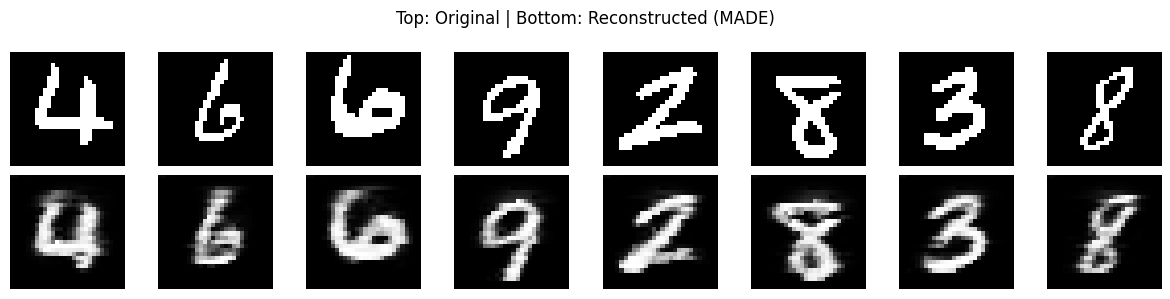

In [72]:
import matplotlib.pyplot as plt

x, _ = next(iter(loader))
x = x[:8].to(device)
x_hat = model(x).detach().cpu()

fig, axs = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axs[0, i].imshow(x[i].view(28, 28).cpu(), cmap='gray')
    axs[1, i].imshow(x_hat[i].view(28, 28), cmap='gray')
    axs[0, i].axis('off')
    axs[1, i].axis('off')
plt.suptitle("Top: Original | Bottom: Reconstructed (MADE)")
plt.tight_layout()
plt.show()


# NADE: Hardcoded Sequential Conditioning
How NADE works:

For each 𝑥𝑖:
Build a separate computation for 𝑝(𝑥𝑖∣𝑥<𝑖)

E.g., for 𝑥3, feed only [𝑥1,𝑥2x ] into the NN

It loops over i=1 to 𝐷

NADE enforces the rule by:
Controlling the inputs given to the NN at each step

One forward pass per output dimension
(slow and sequential)

# MADE: One Pass, Masked Weights
How MADE works:
Feeds full input x into one standard MLP

But uses binary masks on weights so that:

The output neuron for 𝑥𝑖  gets info only from 𝑥1  to 𝑥𝑖−1

MADE enforces the rule by:
Controlling the flow of information inside the network

Only 1 forward pass for all outputs
(fast and parallel)



In [ ]:
# Simlper words 
In NADE, we explicitly compute each conditional probability 𝑝(𝑥𝑖∣𝑥<𝑖) one-by-one by feeding only the prior pixels.

In MADE, we compute all 𝑝(𝑥𝑖∣𝑥<𝑖)  at once using a masked MLP — the entire input is fed in, but the network structure enforces autoregressive dependence.

# PixelCNN — Autoregressive Image Modeling with Convolutions

In [ ]:
Why PixelCNN?

In MADE, we flattened the image → sequence. But:

Images are naturally 2D.

Pixels near each other in space may be far apart in the flattened order.

MADE struggles with that spatial locality [position].

So: 
Can we model p(x₍ᵢⱼ₎ | x_{<ij}) — the pixel at position (i,j), conditioned on all above and left pixels?

Yes you are right, That’s what PixelCNN does.

In [ ]:
| Concept                 | What It Means                                   |
| ----------------------- | ----------------------------------------------- |
| **Autoregressive 2D**   | Predict one pixel at a time using previous ones |
| **Masked convolutions** | Filters that only use "past" pixels             |
| **Log-likelihood loss** | Learn probability distribution over pixels      |
| **Slow sampling**       | One pixel at a time during generation           |


In [73]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float())
])

mnist = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
loader = DataLoader(mnist, batch_size=64, shuffle=True)


In [74]:
import torch
import torch.nn as nn

class MaskedConv2d(nn.Conv2d):
    def __init__(self, mask_type, *args, **kwargs):
        super().__init__(*args, **kwargs)
        assert mask_type in {'A', 'B'}
        self.register_buffer('mask', torch.ones_like(self.weight))
        
        _, _, h, w = self.weight.size()
        yc, xc = h // 2, w // 2

        self.mask[:, :, yc, xc+1:] = 0
        self.mask[:, :, yc+1:] = 0
        if mask_type == 'A':
            self.mask[:, :, yc, xc] = 0  # Mask center for first layer

    def forward(self, x):
        self.weight.data *= self.mask
        return super().forward(x)


In [75]:
class PixelCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            MaskedConv2d('A', 1, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            *[
                nn.Sequential(
                    MaskedConv2d('B', 64, 64, kernel_size=7, padding=3),
                    nn.ReLU()
                ) for _ in range(6)
            ],
            nn.Conv2d(64, 1, kernel_size=1)
        )

    def forward(self, x):
        return self.net(x)


In [76]:
model = PixelCNN().to('cuda')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

for epoch in range(5):
    total_loss = 0
    for x, _ in loader:
        x = x.to('cuda')
        logits = model(x)
        loss = criterion(logits, x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}: Loss = {total_loss / len(loader):.4f}")


Epoch 0: Loss = 0.1558
Epoch 1: Loss = 0.1062
Epoch 2: Loss = 0.0940
Epoch 3: Loss = 0.0874
Epoch 4: Loss = 0.0836


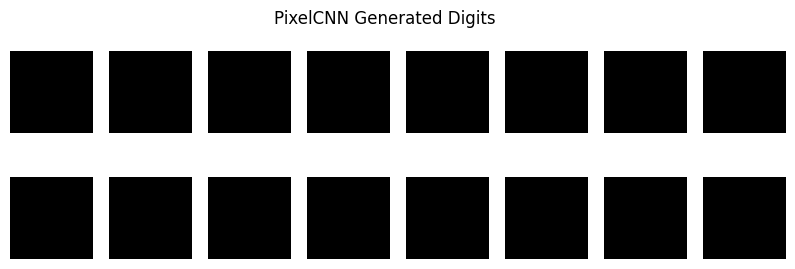

In [77]:
# Sampling one pixel at a time
def sample(model, shape=(16, 1, 28, 28)):
    model.eval()
    x = torch.zeros(shape).to('cuda')
    for i in range(28):
        for j in range(28):
            with torch.no_grad():
                out = torch.sigmoid(model(x))
                x[:, :, i, j] = (out[:, :, i, j] > 0.5).float()
    return x

import matplotlib.pyplot as plt
samples = sample(model).cpu()

fig, axs = plt.subplots(2, 8, figsize=(10, 3))
for i in range(16):
    axs[i//8, i%8].imshow(samples[i][0], cmap='gray')
    axs[i//8, i%8].axis('off')
plt.suptitle("PixelCNN Generated Digits")
plt.show()



PixelCNN++?

PixelCNN++ is an improved version of PixelCNN, designed to be faster, more expressive, and better at modeling real-valued (continuous) images, especially color images.

In [ ]:
| Feature                    | Original PixelCNN             | PixelCNN++                                    |
| -------------------------- | ----------------------------- | --------------------------------------------- |
| **Output Distribution** | Discrete Bernoulli or Softmax | **Discretized Logistic Mixture**              |
| **Sampling Speed**       | Slow (pixel-by-pixel)         | Slightly optimized                            |
|  **Architecture**        | Deep masked convolutions      | **Gated residual blocks**, skip connects      |
|  **Color Modeling**      | Independent channels (naïve)  | **Conditional dependencies** between RGB      |
| **Downsampling**        | Not used                      | **Hierarchical modeling** via striding        |
|  **Performance**         | Good on MNIST                 | **SOTA likelihoods** on CIFAR, ImageNet 32x32 |


In [ ]:
What It Actually Does Better ?

Models images as mixtures of logistics, which are better suited for continuous pixel values
Handles color images more accurately by modeling channel dependencies (e.g., green given red, blue given green)
Uses residual and gating mechanisms for better gradient flow and expressiveness

In [ ]:
Key Equation (Per Pixel): For pixel value 𝑥∈[0,255]

PixelCNN++ models:

𝑝(𝑥)=∑𝜋𝑘⋅Logistic(𝑥∣𝜇𝑘,𝑠𝑘)

Where:

K is the number of mixture components (typically 10)

π k  is the mixture weight

𝜇𝑘,𝑠𝑘  are mean and scale of the logistic

# PixelRNN: Autoregressive Modeling with Recurrent Neural Networks
PixelRNN introduced the idea of autoregressive image modeling

In [ ]:
What Is PixelRNN?

PixelRNN is a generative model that predicts images pixel by pixel, using a recurrent neural network (RNN) to model 
dependencies across rows and columns.

Just like in PixelCNN, we factor the joint probability of the image as:

𝑝(𝑥)=∏∏=𝑝(𝑥𝑖,𝑗∣𝑥<𝑖,𝑗)

Here, 𝑥<𝑖,𝑗  refers to all pixels above and to the left of pixel (𝑖,𝑗)


In [ ]:
Architecture Overview

PixelRNNs use 2D RNNs — that is, recurrence is applied in a 2D grid fashion.

There are two common variants:

| Variant             | Description                                                                                    |
| ------------------- | ---------------------------------------------------------------------------------------------- |
| **Row LSTM**        | Processes each row with an LSTM, from left to right. Each row depends on the previous row.     |
| **Diagonal BiLSTM** | Processes the image along diagonals using bidirectional LSTMs to capture full receptive field. |

    Both are trained to predict the next pixel given all previous pixels.



In [ ]:
# Sampling Procedure

Start with a blank canvas
For each pixel (top-left to bottom-right):
   Run the RNN
   Predict pixel value based on all previous pixels
Add the predicted pixel to the image and move to the next

" Just like a language model predicts next word, PixelRNN predicts next pixel "

In [ ]:
| Feature         | **PixelRNN**      | **PixelCNN**                |
| --------------- | ----------------- | --------------------------- |
| Architecture    | RNN (sequential)  | CNN (parallel with masking) |
| Training speed  | Slow              | Faster                      |
| Sampling speed  | Very slow         | Still slow                  |
| Receptive field | Grows linearly    | Can grow faster with layers |
| Parallelism     | No (sequential) | Yes (during training)     |
| Simplicity      | Complex           | Simpler with masking        |


In [ ]:
PixelRNN was the first serious autoregressive image model, but is largely replaced by PixelCNN due to speed and parallelism.

In [78]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Data loader
transform = transforms.Compose([
    transforms.ToTensor(),  # [0,1]
])
train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)


In [79]:
# pixel RNN (ROW LSTM)
class PixelRNN(nn.Module):
    def __init__(self, input_dim=28, hidden_dim=128):
        super().__init__()
        self.rnn = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, batch_first=True)
        self.output = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        B, C, H, W = x.shape  # B x 1 x 28 x 28
        x = x.squeeze(1)      # B x 28 x 28
        outputs = []

        # Process each row sequentially using row-wise RNN
        for i in range(H):
            row_input = x[:, i, :]                # B x 28
            if i == 0:
                h, c = None, None
            out, (h, c) = self.rnn(row_input.unsqueeze(1), (h, c) if h is not None else None)  # 1-step input
            pred = self.output(out.squeeze(1))    # B x 28
            outputs.append(pred.unsqueeze(1))

        return torch.cat(outputs, dim=1)  # B x 28 x 28


In [80]:
model = PixelRNN().cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

for epoch in range(5):
    total_loss = 0
    for x, _ in train_loader:
        x = x.cuda()
        logits = model(x)
        loss = criterion(logits, x.squeeze(1))  # shape: B x 28 x 28
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}: Loss = {total_loss / len(train_loader):.4f}")


Epoch 0: Loss = 0.1543
Epoch 1: Loss = 0.0707
Epoch 2: Loss = 0.0662
Epoch 3: Loss = 0.0649
Epoch 4: Loss = 0.0642


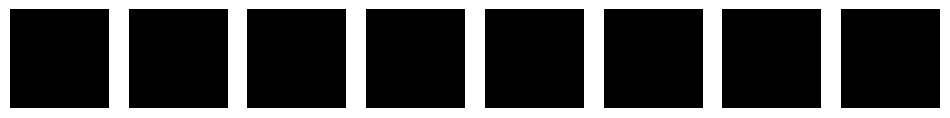

In [81]:
@torch.no_grad()
def sample(model, batch_size=4):
    model.eval()
    samples = torch.zeros(batch_size, 28, 28).cuda()

    for i in range(28):  # row
        h, c = None, None
        for r in range(i + 1):
            row_input = samples[:, r, :].unsqueeze(1)
            out, (h, c) = model.rnn(row_input, (h, c) if h is not None else None)
            pred = torch.sigmoid(model.output(out.squeeze(1)))
            samples[:, r, :] = (pred > 0.5).float()

    return samples.cpu()

# Visualize
import matplotlib.pyplot as plt
samples = sample(model, batch_size=8)
fig, axs = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    axs[i].imshow(samples[i], cmap='gray')
    axs[i].axis('off')
plt.show()


# Normalizing Flows

In [ ]:
Core Idea

We learn a sequence of invertible (bijective) transformations that convert:

Data  𝑥∼𝑝𝑋(𝑥) ⟶ Latent 𝑧 ∼ 𝑁 ( 0, 𝐼)

And we can go backward to generate samples: 𝑧→𝑥



In [ ]:
logpX (x)=logp Z (z)+ ∑ log  det( ∂f / ∂h i−1) 

Where:𝑓𝑖 : invertible functions

𝑧=𝑓𝐾∘⋯∘𝑓1(𝑥)

log𝑝𝑍(𝑧) log-probability of a standard Gaussian

# You start with a simple distribution (like a sphere) and squish, bend, twist, and stretch it (using 𝑓𝑖) until it looks like the data distribution. (Gaussian → Flow → Data)

In [ ]:
A normalizing flow is a series of invertible transformations that map a simple distribution (like a Gaussian) to a complex one. 
It allows us to:

    Sample from complex distributions
    Compute exact likelihoods (thanks to invertibility and the change-of-variable formula)

We transform a simple base distribution (e.g., standard normal) into 
a more complex target distribution using a sequence of invertible functions

In [ ]:
1. Flow model (NormalizingFlow)

This is a chain of transformations (CouplingLayer) that are invertible.

Each transformation:

    Changes the data slightly (learns scaling and translation)
    Keeps track of the log-determinant of the Jacobian so you can compute likelihood

2. Base distribution (Normal)

We are starting from a simple 2D standard Gaussian distribution:

base_dist = Normal(torch.zeros(2).cuda(), torch.ones(2).cuda()) # see the code

This is your prior. It's easy to sample from and compute log-likelihood.


3. the training loop does this 

flow(X_train) applies the forward transformation to the real data → gives latent z and the log-Jacobian determinant log_det.

base_dist.log_prob(z) gives log-probability of those latent values under the base Gaussian.  # see the code

The total log-probability of X is: log⁡pX(x)=log⁡pZ(z)+log⁡∣det⁡∂z∂x∣

The loss is the negative log-likelihood (so we maximize likelihood via gradient descent).

In [ ]:
4. Sampling from the learned distribution

After training, we can generate new sample
First, we sample from a 2D standard normal.

Then, you apply the inverse transformation to get samples in the data space.

This generates new data points similar to your training distribution.

In [ ]:
What is an Invertible Transformation?

An invertible transformation is a function f such that:
x=f(z)andz=f^−1(x)

In other words:
    You can go from data x to latent variable z* using f^−1
    And back from z to x using f

This bijective (one-to-one and onto) property is essential for:

    Mapping between complex and simple distributions
    Calculating exact probability densities using the change of variables theorem

# ----------------------------       Change of Variables Theorem (Core Math)

Use a simple distribution (like Gaussian)
Transform it into a complex one
Still compute its exact probability

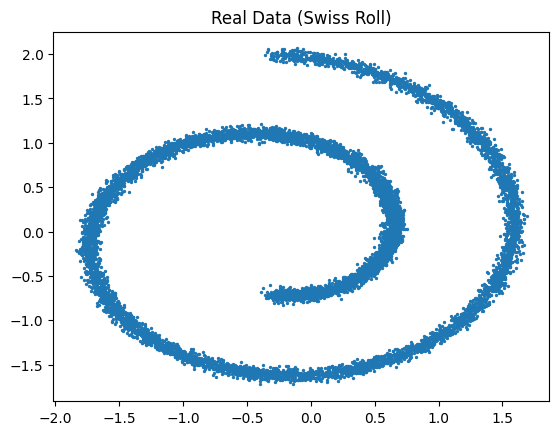

In [82]:
import torch
import matplotlib.pyplot as plt
from sklearn import datasets

X, _ = datasets.make_swiss_roll(n_samples=10000, noise=0.25)
X = X[:, [0, 2]]  # just take 2D
X = (X - X.mean(0)) / X.std(0)
X = torch.tensor(X, dtype=torch.float32)

plt.scatter(X[:, 0], X[:, 1], s=2)
plt.title("Real Data (Swiss Roll)")
plt.show()


In [86]:
# an Affine Coupling Layer (RealNVP block)
import torch.nn as nn

class CouplingLayer(nn.Module):
    def __init__(self, dim, mask):
        super().__init__()
        self.scale = nn.Sequential(nn.Linear(dim, 128), nn.ReLU(), nn.Linear(128, dim))
        self.translate = nn.Sequential(nn.Linear(dim, 128), nn.ReLU(), nn.Linear(128, dim))
        self.register_buffer('mask', mask)  # just ensures mask moves with model

    def forward(self, x):
        x_masked = x * self.mask
        s = self.scale(x_masked) * (1 - self.mask)
        t = self.translate(x_masked) * (1 - self.mask)
        z = x_masked + (1 - self.mask) * (x * torch.exp(s) + t)
        log_det_jacobian = s.sum(dim=1)
        return z, log_det_jacobian

    def inverse(self, z):
        z_masked = z * self.mask
        s = self.scale(z_masked) * (1 - self.mask)
        t = self.translate(z_masked) * (1 - self.mask)
        x = z_masked + (1 - self.mask) * ((z - t) * torch.exp(-s))
        return x



In [87]:
class NormalizingFlow(nn.Module):
    def __init__(self, dim, num_layers=6):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            mask = self._create_mask(dim, parity=(i % 2))
            self.layers.append(CouplingLayer(dim, mask))

    def _create_mask(self, dim, parity):
        mask = torch.arange(dim) % 2
        mask = (mask == parity).float()
        return mask


    def forward(self, x):
        log_det_total = 0
        for layer in self.layers:
            x, log_det = layer(x)
            log_det_total += log_det
        return x, log_det_total

    def inverse(self, z):
        for layer in reversed(self.layers):
            z = layer.inverse(z)
        return z


In [88]:
from torch.distributions.normal import Normal

flow = NormalizingFlow(dim=2).cuda()
optimizer = torch.optim.Adam(flow.parameters(), lr=1e-3)
base_dist = Normal(torch.zeros(2).cuda(), torch.ones(2).cuda())

X_train = X.cuda()
for epoch in range(100):
    z, log_det = flow(X_train)
    log_prob = base_dist.log_prob(z).sum(dim=1)
    loss = - (log_prob + log_det).mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")


Epoch 0: Loss = 3.1259
Epoch 10: Loss = 2.7765
Epoch 20: Loss = 2.6941
Epoch 30: Loss = 2.6345
Epoch 40: Loss = 2.5645
Epoch 50: Loss = 2.4833
Epoch 60: Loss = 2.3964
Epoch 70: Loss = 2.3377
Epoch 80: Loss = 2.2989
Epoch 90: Loss = 2.2520


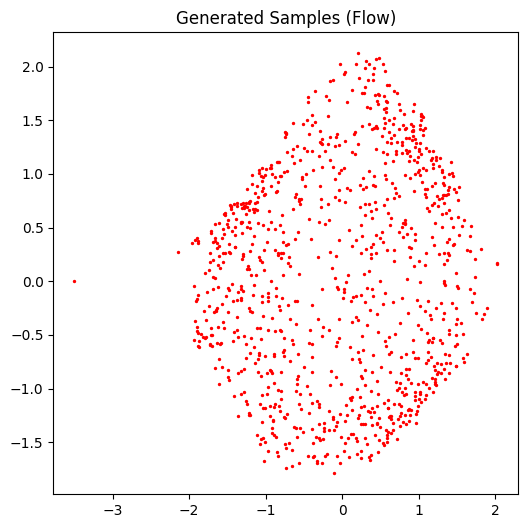

In [89]:
with torch.no_grad():
    z_sample = base_dist.sample((1000,))
    x_sample = flow.inverse(z_sample)

plt.figure(figsize=(6, 6))
plt.scatter(x_sample[:, 0].cpu(), x_sample[:, 1].cpu(), s=2, color='red')
plt.title("Generated Samples (Flow)")
plt.show()


# Diffusion Models 

In [ ]:
# Diffusion Models — Denoising-Based Generative Modeling

Learn to reverse a gradual noising process.

In [ ]:
# Forward Process (Diffusion)
Start from data 𝑥0 , and slowly add noise:

𝑥0→𝑥1→⋯→𝑥𝑇∼𝑁(0,𝐼)

Each step:

𝑞(𝑥𝑡∣𝑥𝑡−1)=𝑁(sqt(1−𝛽)𝑥𝑡−1, 𝛽𝑡𝐼)

At the end (step𝑇), your image becomes pure Gaussian noise.

In [ ]:
# Reverse Process (Learned)

You train a neural network to denoise:

𝑝𝜃(𝑥𝑡−1∣𝑥𝑡)

Your goal is to reconstruct the clean image by reversing the noise gradually.

In [ ]:
# Objective Function (DDPM) 
# Denoising Diffusion Probabilistic Model


Train the model 𝜖𝜃(𝑥𝑡,𝑡) to match the true noise:

𝐿=𝐸𝑥0,𝑡,𝜖[∥𝜖−𝜖𝜃(𝑥𝑡,𝑡)∥^2]


# Sampling Procedure (After Training)
Start from noise 𝑥𝑇∼𝑁(0,𝐼)

Then:

𝑥𝑇→𝑥𝑇−1→⋯→𝑥0x 
 
Each step is a learned denoising with added Gaussian noise

In [ ]:
# intution

Diffusion models learn to generate data by reversing a gradual noising process.

Imagine this:

    You take a real image x0 (like a cat).
    You add Gaussian noise to it over many steps, until it becomes complete noise xT.
    Then, you train a model to reverse this noising process — step by step — going from xT→xT−1→⋯→x0.

That’s a diffusion model.

Two Phases
1. Forward Diffusion (noising)
You gradually corrupt the data:
q(xt∣xt−1)=N(xt;1−βtxt−1,βtI)

    βt is the noise schedule (small noise per step)
    This process is fixed — not learned

Eventually, xT∼N(0,I) (pure noise)

2. Reverse Diffusion (denoising)

You train a model pθ(xt−1∣xt) to recover the data by reversing noise at each step.

    The core idea is to predict the noise added at each step, i.e., learn ϵθ(xt,t)ϵ
    Then subtract it from xtx to get xt−1


# Instead of directly learning xt−1, models often learn to predict the noise
You're training a neural net to predict the noise that was added to the clean image.

In [90]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [91]:
def linear_beta_schedule(timesteps): #2. Linear Beta Schedule
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)


In [92]:
class SimpleDenoiser(nn.Module): # Denoising Model (Simple ConvNet)
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 1, 3, padding=1)
        )
    def forward(self, x, t):
        return self.net(x)  # simple version ignores timestep


In [93]:
# forward diffusion
def q_sample(x_0, t, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod):
    noise = torch.randn_like(x_0)
    return (
        sqrt_alphas_cumprod[t][:, None, None, None] * x_0 +
        sqrt_one_minus_alphas_cumprod[t][:, None, None, None] * noise,
        noise
    )


In [94]:
# Sampling fucntion
@torch.no_grad()
def sample(model, timesteps, shape, device, betas, sqrt_recip_alphas, sqrt_one_minus_alphas_cumprod):
    img = torch.randn(shape, device=device)
    for i in reversed(range(timesteps)):
        t = torch.full((shape[0],), i, device=device, dtype=torch.long)
        noise_pred = model(img, t)
        if i > 0:
            noise = torch.randn_like(img)
        else:
            noise = 0
        beta_t = betas[t][:, None, None, None]
        mean = (1 / sqrt_recip_alphas[t][:, None, None, None]) * (img - beta_t * noise_pred / sqrt_one_minus_alphas_cumprod[t][:, None, None, None])
        img = mean + torch.sqrt(beta_t) * noise
    return img

In [95]:
# Training 
def train_ddpm(epochs=5, timesteps=1000, device="cuda"):
    transform = transforms.Compose([transforms.ToTensor()])
    dataloader = DataLoader(
        datasets.MNIST(root='./data', train=True, download=True, transform=transform),
        batch_size=128, shuffle=True
    )

    model = SimpleDenoiser().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    betas = linear_beta_schedule(timesteps).to(device)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, axis=0)
    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
    sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

    for epoch in range(epochs):
        for x, _ in dataloader:
            x = x.to(device)
            t = torch.randint(0, timesteps, (x.size(0),), device=device)
            x_t, noise = q_sample(x, t, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod)
            noise_pred = model(x_t, t)
            loss = nn.MSELoss()(noise_pred, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

    # Generate images
    samples = sample(model, timesteps, (16, 1, 28, 28), device, betas, sqrt_recip_alphas, sqrt_one_minus_alphas_cumprod)
    samples = samples.cpu().clamp(0, 1)

    fig, axs = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axs.flat):
        ax.imshow(samples[i, 0], cmap='gray')
        ax.axis('off')
    plt.tight_layout()
    plt.show()


Epoch 0: Loss = 0.0485
Epoch 1: Loss = 0.0434
Epoch 2: Loss = 0.0448
Epoch 3: Loss = 0.0517
Epoch 4: Loss = 0.0492


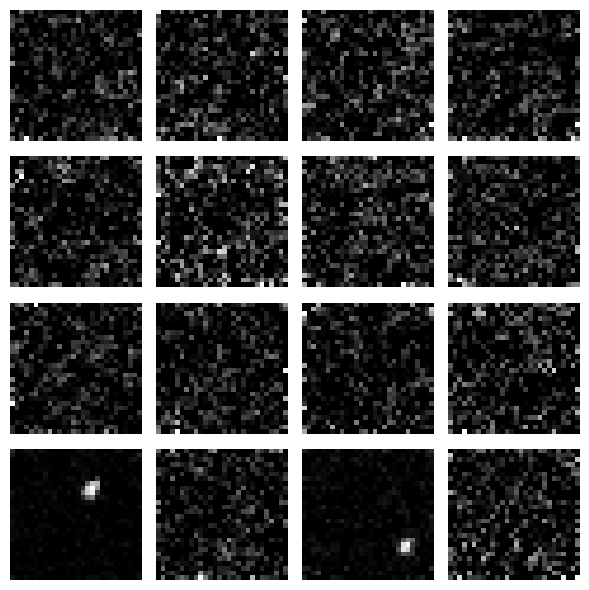

In [96]:
# to run
train_ddpm()


In [ ]:
Why Are Diffusion Models So Popular?

    State-of-the-art in image generation (e.g., DALL·E 2, Stable Diffusion)
    Can generate very high-quality, diverse outputs
    Stable to train, unlike GANs (no adversarial setup)
    Extensible to conditional generation (e.g., with text or class labels)

In [ ]:
Typical Architecture

    U-Net-based neural network
    Time step tt is given as an embedding
    Often uses attention (especially for image models)
    Used with guidance methods like classifier-free guidance